<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== MEG002 — CALIBRATED MESOSCALE TEST ===
Void update rate f_void: 0.916709
Wall update rate f_wall: 0.368640
Δf (void - wall): 0.548068
Temporal Moiré redshift term Δz_temporal: 1.486730


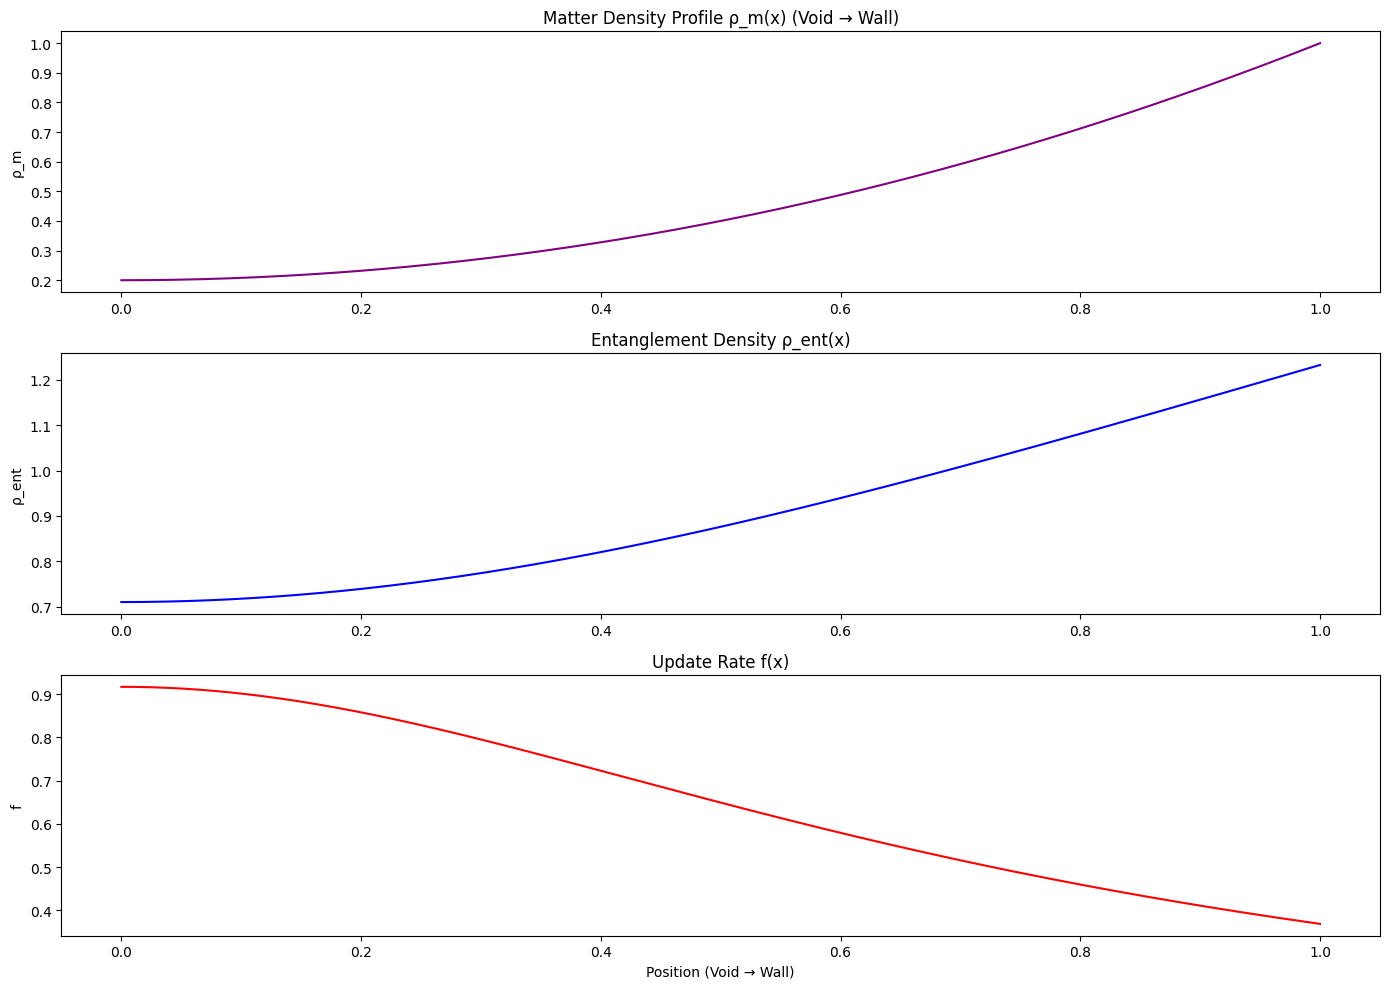

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MEG002 — CALIBRATED MESOSCALE ENTANGLEMENT GRADIENT TEST
# ============================================================

# 1. Synthetic void → wall matter density profile (1D)
N = 1000
x = np.linspace(0, 1, N)

# Matter density: gentle rise from low (void) to high (wall)
rho_m = 0.2 + 0.8 * x**2   # 0.2 → 1.0

# 2. Entanglement density ρ_ent(x)
# Use a saturating, logarithmic-like response to avoid huge contrasts
rho0 = 0.5     # baseline entanglement density
alpha = 0.8    # scaling factor
beta = 1.5     # sensitivity

rho_ent = rho0 + alpha * np.log1p(beta * rho_m)

# 3. Curvature compensation load C(x)
# Softer, sublinear dependence on matter density
gamma = 1.2
C = 1.0 + gamma * np.sqrt(rho_m)

# 4. Update-rate map f(x)
# HES-style: f = 1 / (ρ_ent * C)
f = 1.0 / (rho_ent * C)

# 5. Extract void and wall update rates
f_void = f[0]      # lowest density region
f_wall = f[-1]     # highest density region
delta_f = f_void - f_wall

# 6. Temporal Moiré redshift term
delta_z_temporal = (f_void - f_wall) / f_wall

# ============================================================
# PRINT RESULTS
# ============================================================

print("=== MEG002 — CALIBRATED MESOSCALE TEST ===")
print(f"Void update rate f_void: {f_void:.6f}")
print(f"Wall update rate f_wall: {f_wall:.6f}")
print(f"Δf (void - wall): {delta_f:.6f}")
print(f"Temporal Moiré redshift term Δz_temporal: {delta_z_temporal:.6f}")

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(14, 10))

plt.subplot(3,1,1)
plt.plot(x, rho_m, color='purple')
plt.title("Matter Density Profile ρ_m(x) (Void → Wall)")
plt.ylabel("ρ_m")

plt.subplot(3,1,2)
plt.plot(x, rho_ent, color='blue')
plt.title("Entanglement Density ρ_ent(x)")
plt.ylabel("ρ_ent")

plt.subplot(3,1,3)
plt.plot(x, f, color='red')
plt.title("Update Rate f(x)")
plt.ylabel("f")
plt.xlabel("Position (Void → Wall)")

plt.tight_layout()
plt.show()
